Catatan: Di sini memerlukan import file `02_model1_features_emiten.pkl` yang didapatkan dari `02_Linear_vs_Tree.ipynb`

# Import dan Load

In [1]:
# Library olah data default
import pandas as pd
import numpy as np

# Import dan Eksport .pkl
import joblib
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib import rcParams

# Analisis Panel
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score

In [2]:
rcParams['figure.figsize'] = 15, 8
mpl.style.use(['ggplot'])

In [3]:
df_property = pd.read_excel('https://drive.google.com/uc?id=1jk8SfEEmw80GQCA-2TekI8zmX0tjPK4J', sheet_name='HASIL PERHITUNGAN')

In [4]:
# Pastikan data diurutkan berdasarkan waktu
df_property = df_property.sort_values(by=['Emiten', 'Tahun'])
df_property.head(10)

,Emiten,Tahun,DER,TDR,ROE,TAN,LIQ,GRW,SIZ,TAX,AGE,NDTS
0,APLN,2020,1.676421,0.626367,0.015864,0.615793,1.895883,0.306884,31.045179,0.171031,2.302585,0.006210
1,APLN,2021,1.809463,0.644060,-0.046038,0.596135,1.634991,-0.141250,31.019171,0.330957,2.397895,0.009656
2,APLN,2022,1.295011,0.564272,0.181956,0.605022,1.958465,1.035556,30.985049,0.083012,2.484907,0.008786
3,APLN,2023,1.105918,0.525148,0.086572,0.607771,1.301291,-0.460209,30.974856,0.212327,2.564949,0.008564
4,APLN,2024,0.894971,0.472287,0.055901,0.584041,2.433227,0.192468,30.893710,0.144194,2.639057,0.007938
5,ASRI,2020,1.261504,0.557816,-0.110441,0.898430,0.674138,-0.593388,30.686286,0.656215,2.564949,0.004944
6,ASRI,2021,1.300101,0.565237,0.014988,0.861657,0.835173,1.014732,30.719058,0.078513,2.639057,0.002850
7,ASRI,2022,1.095247,0.522729,0.103204,0.836935,0.978071,0.578160,30.735560,0.057735,2.708050,0.002754
8,ASRI,2023,0.972839,0.493116,0.056573,0.869344,0.787737,-0.119620,30.732744,0.077696,2.772589,0.002225
9,ASRI,2024,0.942443,0.485184,0.005746,0.871374,0.764560,-0.132122,30.722928,0.084770,2.833213,0.002450


# Preprocessing

## Menambah Kolom Emiten Top

Ini didapat dari notebook sebelumnya. Daripada melakukan transformasi One-Hot-Encoding yang akan menghasilkan kolom terlalu banyak, cukup tambahkan 1 kolom saja yang berisi Emiten yang jadi fitur penting pada tahap sebelumnya.

In [5]:
emiten_top = joblib.load('02_model1_features_emiten.pkl')
emiten_top

['PPRO', 'MDLN', 'EMDE', 'DART']

Jika Emiten adalah yang Top, maka 1. Jika tidak maka 0

In [6]:
# ==========================================
# LAKUKAN FEATURE ENGINEERING
# ==========================================
# 1. Penyederhanaan Emiten (Top Emiten = 1, Sisanya = 0)

df_property['Is_Top_Emiten'] = df_property['Emiten'].apply(lambda x: 1 if x in emiten_top else 0)

In [8]:
df_property.sample(10)

,Emiten,Tahun,DER,TDR,ROE,TAN,LIQ,GRW,SIZ,TAX,AGE,NDTS,Is_Top_Emiten
168,RBMS,2023,0.429190,0.300303,-0.041560,0.778568,2.368814,0.549755,27.291456,-0.261500,3.258097,0.029169,0
172,RDTX,2022,0.139541,0.122454,0.091106,0.793826,2.632456,0.231958,28.851060,0.190932,3.465736,0.001508,0
50,DART,2020,1.284102,0.562191,-0.137323,0.972601,0.299288,-0.297568,29.526558,-0.098090,3.401197,0.010436,1
36,BKSL,2021,0.588300,0.370396,0.021864,0.720527,2.833762,1.015525,30.443731,0.180238,3.178054,0.000705,0
57,DILD,2022,1.630753,0.619881,0.030885,0.604961,1.043337,0.197868,30.425362,0.069328,3.433987,0.001813,0
144,OMRE,2024,0.159799,0.137781,-0.042386,0.983070,0.145443,-0.111017,29.022719,-0.021262,3.401197,0.000929,0
152,PPRO,2022,3.788211,0.791154,0.005329,0.375602,1.528018,0.976519,30.713527,0.288076,1.945910,0.001717,1
26,BIPP,2021,0.853836,0.460578,0.017726,0.650126,1.709839,-0.445131,28.346557,0.179278,3.258097,0.003347,0
96,JRPT,2021,0.440820,0.305951,0.096486,0.712894,1.027338,-0.004851,30.094717,0.087127,3.295837,0.000912,0
76,FMII,2021,0.367049,0.268497,0.013469,0.714545,1.279982,0.027620,27.490644,0.051741,3.044522,0.000144,0


## Menggeser Data (Menambah Lag)

Untuk memprediksi data tahun depan dengan menambah kolom dari variabel Y (DER) tahun depan

In [9]:
# 2. Buat Target Masa Depan (DER Tahun Depan)
df_property['Target_DER_Depan'] = df_property.groupby('Emiten')['DER'].shift(-1)

# 3. Buat Variabel Masa Lalu (DER Tahun Ini, untuk memprediksi tahun depan)
# Karena kita sudah menggeser target ke depan, kolom 'DER' asli otomatis berfungsi sebagai Lag.
df_property.head()

,Emiten,Tahun,DER,TDR,ROE,TAN,LIQ,GRW,SIZ,TAX,AGE,NDTS,Is_Top_Emiten,Target_DER_Depan
0,APLN,2020,1.676421,0.626367,0.015864,0.615793,1.895883,0.306884,31.045179,0.171031,2.302585,0.006210,0,1.809463
1,APLN,2021,1.809463,0.644060,-0.046038,0.596135,1.634991,-0.141250,31.019171,0.330957,2.397895,0.009656,0,1.295011
2,APLN,2022,1.295011,0.564272,0.181956,0.605022,1.958465,1.035556,30.985049,0.083012,2.484907,0.008786,0,1.105918
3,APLN,2023,1.105918,0.525148,0.086572,0.607771,1.301291,-0.460209,30.974856,0.212327,2.564949,0.008564,0,0.894971
4,APLN,2024,0.894971,0.472287,0.055901,0.584041,2.433227,0.192468,30.893710,0.144194,2.639057,0.007938,0,NaN


In [10]:
# Buang baris yang tidak punya "Tahun Depan"
df_pred_der = df_property.dropna(subset=['Target_DER_Depan'])

## Train-Test Split (Time-Based)

Tidak seperti train-test split biasa, untuk data waktu, harus ditentukan tahun pembatas untuk split. Jadi menggunakan data tahun historis untuk memprediksi masa depan. Ini untuk mencegah memprediksi data tahun lalu menggunakan informasi dari masa depan.

In [11]:
# ==========================================
# TIME-BASED SPLIT (Pemisahan Waktu)
# ==========================================
tahun_batas = 2023
train = df_pred_der[df_pred_der['Tahun'] < tahun_batas]
test = df_pred_der[df_pred_der['Tahun'] >= tahun_batas]

In [12]:
# Fitur yang digunakan: Rasio Keuangan + DER saat ini (sebagai prediktor) + Kelompok Emiten
fitur = ['ROE', 'TAN', 'LIQ', 'GRW', 'SIZ', 'TAX', 'AGE', 'NDTS', 'DER', 'Is_Top_Emiten']

X_train = train[fitur]
y_train = train['Target_DER_Depan']

X_test = test[fitur]
y_test = test['Target_DER_Depan']

# Pembangunan Model Awal

In [13]:
# ==========================================
# TRAINING & EVALUASI
# ==========================================
rf_non_tune = RandomForestRegressor(n_estimators=100, random_state=42)
rf_non_tune.fit(X_train, y_train)

y_non_tune = rf_non_tune.predict(X_test)

print("=== AKURASI PREDIKSI MASA DEPAN (DER) ===")
print(f"R-Squared: {r2_score(y_test, y_non_tune):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_non_tune):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_non_tune)):.4f}")

=== AKURASI PREDIKSI MASA DEPAN (DER) ===
R-Squared: 0.6502
MAE: 0.2611
RMSE: 0.7269


In [14]:
# Lihat Feature Importance yang BARU!
importances_awal = pd.DataFrame({
    'Fitur': fitur,
    'Kekuatan': rf_non_tune.feature_importances_
}).sort_values(by='Kekuatan', ascending=False)

# print("\n=== FEATURE IMPORTANCE FORECASTING ===")
# importances_awal

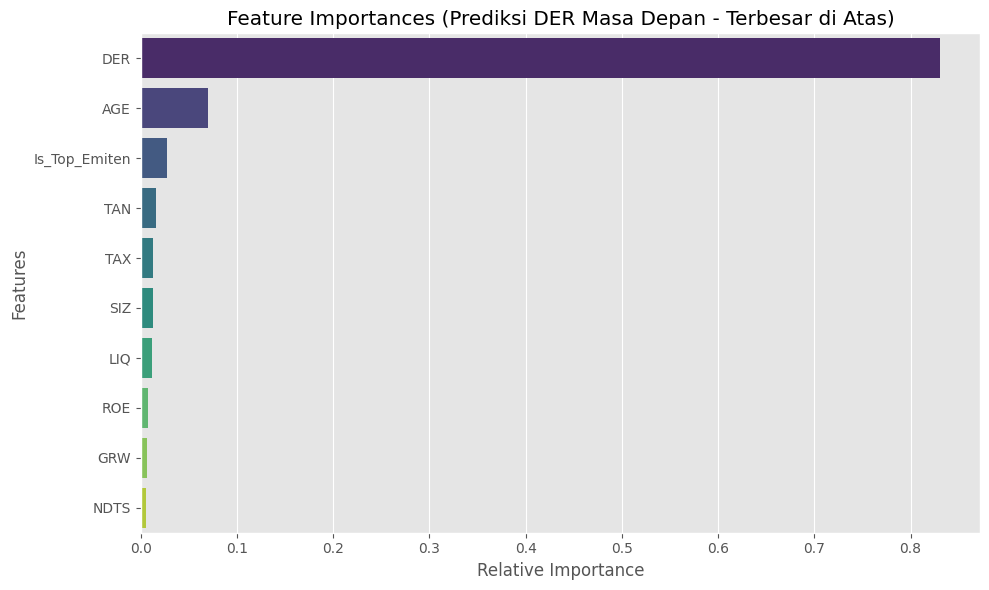

In [15]:
# Visualisasi menggunakan Seaborn (Inverted: Terbesar di atas)
plt.figure(figsize=(10, 6))
sns.barplot(data=importances_awal, x='Kekuatan', y='Fitur', hue='Fitur', palette='viridis', legend=False)
plt.title('Feature Importances (Prediksi DER Masa Depan - Terbesar di Atas)')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Hyperparameter Tuning

In [16]:
# 2. Setup TimeSeriesSplit
# Karena T kecil (4 tahun efektif), kita gunakan n_splits kecil, misal 3
tscv = TimeSeriesSplit(n_splits=3)

# 3. Inisialisasi Model & Hyperparameter Tuning
rf_tuning = RandomForestRegressor(random_state=42)

In [17]:
scores_cv = cross_val_score(rf_tuning, X_train, y_train, cv=tscv, scoring='r2')
print("R2 masing-masing = ", scores_cv)
print("Rata-rata = ", scores_cv.mean())

R2 masing-masing =  [0.64984523 0.85088109 0.51274676]
Rata-rata =  0.6711576949904009


## Tanpa Parameter Default

Untuk mencegah overfitting

In [18]:
parameters_rf1 = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 4, 5],            # Dibatasi agar tidak overfit pada N=40
    'min_samples_leaf': [5, 10],       # Memastikan generalisasi
    'max_features': ['sqrt', None]     # 'None' berarti menggunakan semua fitur
}

Estimasi 40-an detik

In [19]:
# Grid Search dengan Cross Validation khusus waktu
search_rf1 = GridSearchCV(
    estimator=rf_tuning,
    param_grid=parameters_rf1,
    cv=tscv,
    scoring='r2',
    verbose=3,
    n_jobs=-1
)

search_rf1.fit(X_train, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
             estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 4, 5], 'max_features': ['sqrt', None],
                         'min_samples_leaf': [5, 10],
                         'n_estimators': [100, 200, 500]},
             scoring='r2', verbose=3)

In [20]:
print("Best Parameters:", search_rf1.best_params_)
print("Best Score:", search_rf1.best_score_)

Best Parameters: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 5, 'n_estimators': 500}
Best Score: 0.6448172290113878


In [21]:
rf1_tuned = search_rf1.best_estimator_

In [22]:
rf1_cv = cross_val_score(rf1_tuned, X_train, y_train, cv=tscv, scoring='r2')
print("R2 masing-masing = ", rf1_cv)
print("Rata-rata = ", rf1_cv.mean())

R2 masing-masing =  [0.56682686 0.86018385 0.50744097]
Rata-rata =  0.6448172290113878


## Pakai Parameter Default

In [23]:
parameters_rf2 = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 4, 5, None],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', None, 1.0]
}

Estimasi 2 menit

In [24]:
# Grid Search dengan Cross Validation khusus waktu
search_rf2 = GridSearchCV(
    estimator=rf_tuning,
    param_grid=parameters_rf2,
    cv=tscv,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

search_rf2.fit(X_train, y_train)

Fitting 3 folds for each of 108 candidates, totalling 324 fits


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
             estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 4, 5, None],
                         'max_features': ['sqrt', None, 1.0],
                         'min_samples_leaf': [1, 5, 10],
                         'n_estimators': [100, 200, 500]},
             scoring='r2', verbose=1)

In [25]:
print("Best Parameters:", search_rf2.best_params_)
print("Best Score:", search_rf2.best_score_)

Best Parameters: {'max_depth': 4, 'max_features': None, 'min_samples_leaf': 1, 'n_estimators': 500}
Best Score: 0.6764319310919897


In [26]:
rf2_tuned = search_rf2.best_estimator_

In [27]:
rf2_cv = cross_val_score(rf2_tuned, X_train, y_train, cv=tscv, scoring='r2')
print("R2 masing-masing = ", rf2_cv)
print("Rata-rata = ", rf2_cv.mean())

R2 masing-masing =  [0.65920818 0.8450907  0.52499691]
Rata-rata =  0.6764319310919897


## Visualisasi Sebelum dan Sesudah Tuning

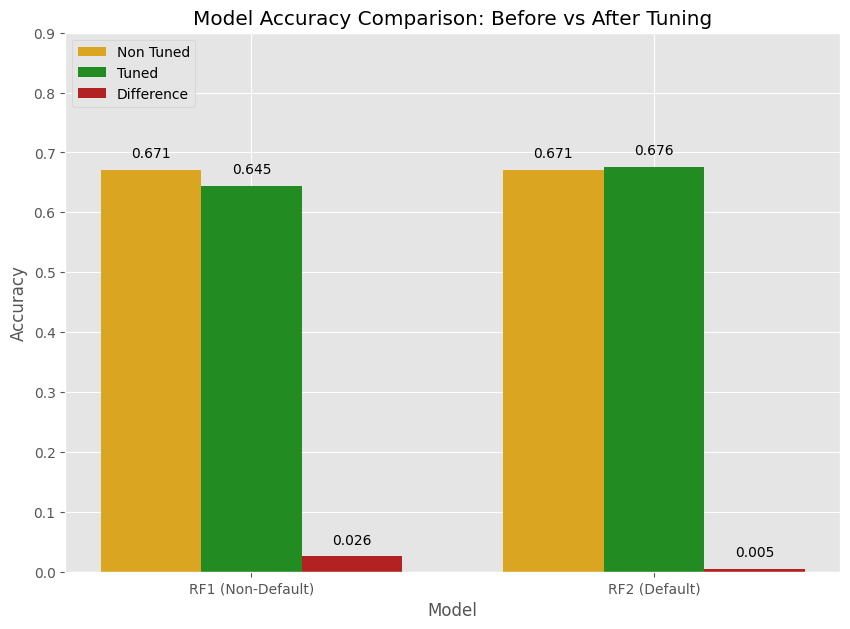

In [28]:
def addlabels(x,y,z):
    for i in range(len(x)):
      plt.text(i, x[i]+0.02, format(x[i], ".3f"), ha = 'center')
      plt.text(i+0.25, y[i]+0.02, format(y[i], ".3f"), ha = 'center')
      plt.text(i+0.5, z[i]+0.02, format(z[i], ".3f"), ha = 'center')

N = 2
ind = np.arange(N)
width = 0.25

plt.figure(figsize=(10,7))

non_tuning_acc = [scores_cv.mean(), scores_cv.mean()]
bar1 = plt.bar(ind, non_tuning_acc, width, color='goldenrod')

tuning_acc = [rf1_cv.mean(), rf2_cv.mean()]
bar2 = plt.bar(ind+width, tuning_acc, width, color='forestgreen')

selisih = []
for i in range(0, len(non_tuning_acc)):
  selisih.append(np.abs(non_tuning_acc[i]-tuning_acc[i]))

bar3 = plt.bar(ind+width*2, selisih, width, color = 'firebrick')

addlabels(non_tuning_acc, tuning_acc, selisih)
plt.xlabel("Model")
plt.ylabel('Accuracy')
plt.ylim([0, 0.9])

plt.xticks(ind+width,['RF1 (Non-Default)', 'RF2 (Default)'])
plt.legend( (bar1, bar2, bar3), ('Non Tuned', 'Tuned', 'Difference'), loc='upper left' )
plt.title("Model Accuracy Comparison: Before vs After Tuning")
plt.show()

# Evaluasi

## Data Train

In [29]:
y_val_non_tune = rf_non_tune.predict(X_train)

print("=== AKURASI PREDIKSI MASA DEPAN (DER) ===")
print(f"R-Squared: {r2_score(y_train, y_val_non_tune):.4f}")
print(f"MAE: {mean_absolute_error(y_train, y_val_non_tune):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_val_non_tune)):.4f}")

=== AKURASI PREDIKSI MASA DEPAN (DER) ===
R-Squared: 0.9746
MAE: 0.0566
RMSE: 0.1241


In [30]:
rf1_tuned.fit(X_train, y_train)

y_val_rf1 = rf1_tuned.predict(X_train)

print("=== R2 Pada Data Train ===")
print(f"R-Squared: {r2_score(y_train, y_val_rf1):.4f}")
print(f"MAE: {mean_absolute_error(y_train, y_val_rf1):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_val_rf1)):.4f}")

=== R2 Pada Data Train ===
R-Squared: 0.8488
MAE: 0.1239
RMSE: 0.3029


In [31]:
rf2_tuned.fit(X_train, y_train)

y_val_rf2 = rf2_tuned.predict(X_train)

print("=== R2 Pada Data Train ===")
print(f"R-Squared: {r2_score(y_train, y_val_rf2):.4f}")
print(f"MAE: {mean_absolute_error(y_train, y_val_rf2):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_val_rf2)):.4f}")

=== R2 Pada Data Train ===
R-Squared: 0.9688
MAE: 0.0817
RMSE: 0.1375


## Data Test

In [32]:
y_pred_non_tune = rf_non_tune.predict(X_test)

print("=== AKURASI PREDIKSI MASA DEPAN (DER) ===")
print(f"R-Squared: {r2_score(y_test, y_pred_non_tune):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_non_tune):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_non_tune)):.4f}")

=== AKURASI PREDIKSI MASA DEPAN (DER) ===
R-Squared: 0.6502
MAE: 0.2611
RMSE: 0.7269


In [33]:
y_pred_rf1 = rf1_tuned.predict(X_test)

print("=== R2 Pada Data Test ===")
print(f"R-Squared: {r2_score(y_test, y_pred_rf1):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf1):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf1)):.4f}")

=== R2 Pada Data Test ===
R-Squared: 0.6134
MAE: 0.2575
RMSE: 0.7642


In [34]:
y_pred_rf2 = rf2_tuned.predict(X_test)

print("=== R2 Pada Data Test ===")
print(f"R-Squared: {r2_score(y_test, y_pred_rf2):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf2):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf2)):.4f}")

=== R2 Pada Data Test ===
R-Squared: 0.6160
MAE: 0.2712
RMSE: 0.7616


## Analisis Penyebab Penurunan Performa (Diagnosis)

Kita akan membandingkan performa Data Train vs Data Test untuk melihat apakah terjadi **Overfitting**, serta membandingkan *Feature Importance* antara model awal dan model hasil tuning.

In [35]:
# 1. Perbandingan R2 Train vs Test untuk deteksi Overfitting
summary_performa = pd.DataFrame({
    'Model': ['Non-Tuned', 'RF1 Tuned', 'RF2 Tuned'],
    'R2_Train': [
        r2_score(y_train, y_val_non_tune),
        r2_score(y_train, y_val_rf1),
        r2_score(y_train, y_val_rf2)
    ],
    'R2_Test': [
        r2_score(y_test, y_pred_non_tune),
        r2_score(y_test, y_pred_rf1),
        r2_score(y_test, y_pred_rf2)
    ]
})

summary_performa['Gap_Train_Test'] = summary_performa['R2_Train'] - summary_performa['R2_Test']
display(summary_performa)

,Model,R2_Train,R2_Test,Gap_Train_Test
0,Non-Tuned,0.974608,0.650201,0.324407
1,RF1 Tuned,0.848761,0.613422,0.235340
2,RF2 Tuned,0.968829,0.616006,0.352823


In [36]:
# 2. Cek apakah Feature Importance bergeser secara signifikan
importances_tuned = pd.DataFrame({
    'Fitur': fitur,
    'Kekuatan_Awal': rf_non_tune.feature_importances_,
    'Kekuatan_Tuned_RF1': rf1_tuned.feature_importances_,
    'Kekuatan_Tuned_RF2': rf2_tuned.feature_importances_
}).sort_values(by='Kekuatan_Awal', ascending=False)

importances_tuned

,Fitur,Kekuatan_Awal,Kekuatan_Tuned_RF1,Kekuatan_Tuned_RF2
8,DER,0.830677,0.913882,0.817344
6,AGE,0.070141,0.001409,0.082205
9,Is_Top_Emiten,0.026762,0.071088,0.031864
1,TAN,0.016196,0.001991,0.012140
5,TAX,0.012772,0.001660,0.010932
4,SIZ,0.012309,0.001936,0.010576
2,LIQ,0.012012,0.002049,0.015845
0,ROE,0.007076,0.002620,0.006976
3,GRW,0.006665,0.002592,0.005413
7,NDTS,0.005389,0.000772,0.006704


Jika `Gap_Train_Test` sangat besar (misal R2 Train 0.96 tapi Test 0.61), itu tandanya model terlalu 'menghafal' data masa lalu dan gagal melakukan generalisasi pada data tahun 2024 (Data Test). Hal ini sering terjadi jika `min_samples_leaf` atau `max_depth` hasil tuning masih membolehkan model terlalu kompleks untuk jumlah data yang sedikit.

## Visualisasi Prediksi dan Aktual

In [42]:
actual_vs_prediction = pd.DataFrame({
    'Actual_DER_Next_Year': y_test,
    'RF_Non_Tune': y_pred_non_tune,
    'RF1': y_pred_rf1,
    'RF2': y_pred_rf2
})

# Reset index for a cleaner look
actual_vs_prediction = actual_vs_prediction.reset_index(drop=True)

actual_vs_prediction.sample(5)

,Actual_DER_Next_Year,RF_Non_Tune,RF1,RF2
10,0.910302,0.934614,0.921757,0.915773
37,0.078370,0.173323,0.185535,0.191175
36,0.312144,0.380153,0.354987,0.371738
25,0.219123,0.279371,0.259041,0.248965
23,0.737931,1.477739,1.480441,1.452447


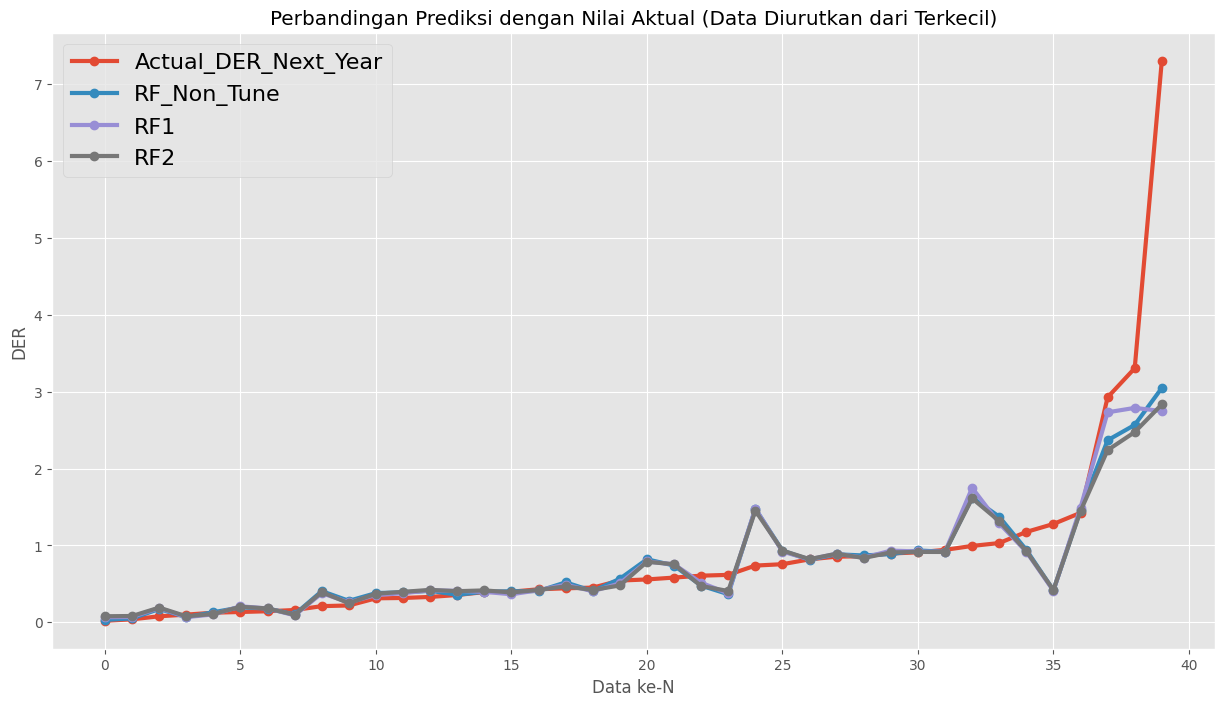

In [44]:
plt.plot(actual_vs_prediction.sort_values(by ='Actual_DER_Next_Year').reset_index(drop = True),
         linewidth = 3,
         marker = 'o'
         )
plt.title('Perbandingan Prediksi dengan Nilai Aktual (Data Diurutkan dari Terkecil)')
plt.xlabel('Data ke-N')
plt.ylabel('DER')
plt.legend(actual_vs_prediction.columns, fontsize=16)
plt.show()

Dari visualisasi dapat terlihat bahwa R1 lebih baik untuk generalisasi. Karena 3 data terakhir memiliki nilai DER yang cukup outlier dan meningkat drastis. Karena ini, DER dinilai "kurang" oleh metrik R2 karena di-punish terlalu besar.

# Export dan Kesimpulan

Kesimpulan yang didapatkan:

* Performa R2 (baik di data train ataupun test) pada Random Forest Non-Tune agak kontradiksi karena mengalahkan Random Forest yang sudah di-tuning. Hal ini bisa terjadi karena model **overfitting**. Hal ini juga bisa terjadi untuk data yang tergolong kecil karena hanya memiliki rentang 5 tahun. Model Non-Tune memiliki performa lebih baik murni sebagai keberuntungan saja karena memprediksi rentang waktu yang pendek.
* Hal yang lebih diperhitungkan dalam pemilihan model adalah `Gap_Train_Test`. Untuk Model RF1, walaupun R2 Train nya rendah, namun memiliki performa R2 Test yang tidak beda jauh dari model lain. Sehingga `Gap_Train_Test` RF1 paling rendah. Ini berarti model tidak overfit, dan lebih bisa digunakan untuk generalisasi dan prediksi masa mendatang.
* Performa MAE pada RF1 justru yang terbaik. Ini bisa menjadi pertimbangan juga untuk alasan pemilihan RF1 sebagai model final.

In [38]:
# 1. Custom Transformer untuk Feature Engineering
class TopEmitenTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, emiten_list):
        self.emiten_list = emiten_list

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        # Jika input adalah DataFrame dan kolom 'Emiten' ada
        if 'Emiten' in X_copy.columns:
            X_copy['Is_Top_Emiten'] = X_copy['Emiten'].apply(lambda x: 1 if x in self.emiten_list else 0)
            # Pastikan urutan fitur sama dengan saat training
            return X_copy[fitur]
        return X_copy

# 2. Buat Pipeline
# Catatan: Kita menggunakan rf1_tuned yang sudah di-fit sebelumnya
forecasting_pipeline = Pipeline([
    ('feature_eng', TopEmitenTransformer(emiten_top)),
    ('rf_model', rf1_tuned)
])

# 3. Export Pipeline
joblib.dump(forecasting_pipeline, '03_model_rf_der.pkl')

print("Model Pipeline berhasil diekspor ke: 03_model_rf_der.pkl")

Model Pipeline berhasil diekspor ke: 03_model_rf_der.pkl
